# Week 1: Foundation + EDA
## TruthLens — Fake News Detector

**Goal**: Exploratory Data Analysis on fake news dataset (40k articles)

**Deliverable**: 
- Dataset loaded
- 3 visualizations (class distribution, text length histogram, label counts)
- Basic observations documented

## 1. Setup & Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

Matplotlib is building the font cache; this may take a moment.


## 2. Load Dataset

In [2]:
# Load the dataset
# Download from: https://www.kaggle.com/datasets/clementbisaillon/fake-and-real-news-dataset
# Extract to: data/

try:
    # Load real news (label = 0)
    df_real = pd.read_csv('../data/True.csv')
    df_real['label'] = 0  # 0 = Real news
    
    # Load fake news (label = 1)
    df_fake = pd.read_csv('../data/Fake.csv')
    df_fake['label'] = 1  # 1 = Fake news
    
    # Combine datasets
    df = pd.concat([df_real, df_fake], ignore_index=True)
    
    print(f"✓ Dataset loaded successfully!")
    print(f"Real articles: {len(df_real):,}")
    print(f"Fake articles: {len(df_fake):,}")
    print(f"Total articles: {len(df):,}")
except FileNotFoundError:
    print("❌ Dataset files not found. Please ensure:")
    print("   - True.csv exists in ../data/")
    print("   - Fake.csv exists in ../data/")
    print("   Download from: https://www.kaggle.com/datasets/clementbisaillon/fake-and-real-news-dataset")

✓ Dataset loaded successfully!
Real articles: 21,417
Fake articles: 23,481
Total articles: 44,898


## 3. Basic Info & Data Exploration

In [3]:
# Display basic information
print("Dataset Info:")
print(f"  Shape: {df.shape}")
print(f"\nColumn Names & Types:")
print(df.info())
print(f"\nFirst few rows:")
df.head()

Dataset Info:
  Shape: (44898, 5)

Column Names & Types:
<class 'pandas.DataFrame'>
RangeIndex: 44898 entries, 0 to 44897
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   title    44898 non-null  str  
 1   text     44898 non-null  str  
 2   subject  44898 non-null  str  
 3   date     44898 non-null  str  
 4   label    44898 non-null  int64
dtypes: int64(1), str(4)
memory usage: 112.3 MB
None

First few rows:


,title,text,subject,date,label
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017",0
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017",0
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017",0
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017",0
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017",0


In [4]:
# Check for missing values
print("Missing Values:")
print(df.isnull().sum())
print(f"\nMissing percentage:")
print((df.isnull().sum() / len(df) * 100).round(2))

Missing Values:
title      0
text       0
subject    0
date       0
label      0
dtype: int64

Missing percentage:
title      0.0
text       0.0
subject    0.0
date       0.0
label      0.0
dtype: float64


In [5]:
# Check label distribution
print("Label Distribution:")
print(df['label'].value_counts())
print(f"\nPercentages:")
print(df['label'].value_counts(normalize=True).round(4))

Label Distribution:
label
1    23481
0    21417
Name: count, dtype: int64

Percentages:
label
1    0.523
0    0.477
Name: proportion, dtype: float64


## 4. Text Analysis

In [6]:
# Calculate text statistics
df['text_length'] = df['text'].astype(str).apply(len)
df['word_count'] = df['text'].astype(str).apply(lambda x: len(x.split()))

print("Text Statistics:")
print(f"  Avg length: {df['text_length'].mean():.0f} characters")
print(f"  Min length: {df['text_length'].min()} characters")
print(f"  Max length: {df['text_length'].max()} characters")
print(f"\n  Avg words: {df['word_count'].mean():.0f}")
print(f"  Min words: {df['word_count'].min()}")
print(f"  Max words: {df['word_count'].max()}")

Text Statistics:
  Avg length: 2469 characters
  Min length: 1 characters
  Max length: 51794 characters

  Avg words: 405
  Min words: 0
  Max words: 8135


In [7]:
# Compare by label
print("\nText Length by Label:")
print(df.groupby('label')['text_length'].describe().round(0))
print("\nWord Count by Label:")
print(df.groupby('label')['word_count'].describe().round(0))


Text Length by Label:
         count    mean     std  min     25%     50%     75%      max
label                                                               
0      21417.0  2383.0  1685.0  1.0   914.0  2222.0  3237.0  29781.0
1      23481.0  2547.0  2533.0  1.0  1433.0  2166.0  3032.0  51794.0

Word Count by Label:
         count   mean    std  min    25%    50%    75%     max
label                                                         
0      21417.0  386.0  274.0  0.0  148.0  359.0  525.0  5172.0
1      23481.0  423.0  408.0  0.0  240.0  363.0  506.0  8135.0


## 5. Visualizations

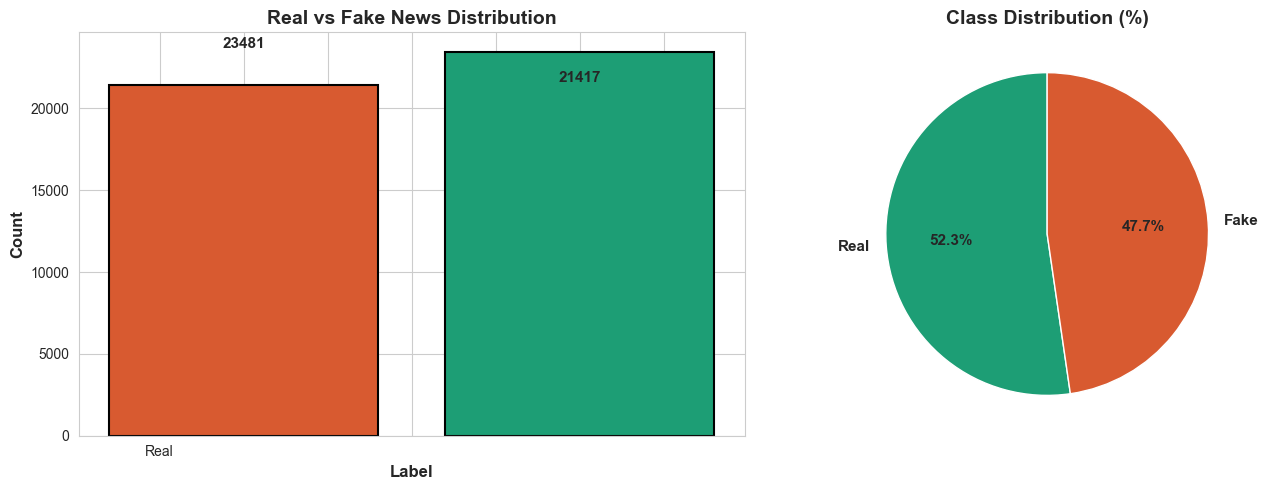

✓ Saved: eda_class_dist.png


In [8]:
# 1. Class Distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar plot
label_counts = df['label'].value_counts()
colors = ['#1D9E75', '#D85A30']  # Green for real, orange for fake
axes[0].bar(label_counts.index, label_counts.values, color=colors, edgecolor='black', linewidth=1.5)
axes[0].set_xlabel('Label', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Count', fontsize=12, fontweight='bold')
axes[0].set_title('Real vs Fake News Distribution', fontsize=14, fontweight='bold')
axes[0].set_xticklabels(['Real' if x == 0 else 'Fake' for x in label_counts.index])

# Add value labels
for i, v in enumerate(label_counts.values):
    axes[0].text(i, v + 200, str(v), ha='center', fontweight='bold', fontsize=11)

# Pie chart
axes[1].pie(label_counts.values, labels=['Real', 'Fake'], autopct='%1.1f%%', 
             colors=colors, startangle=90, textprops={'fontsize': 11, 'fontweight': 'bold'})
axes[1].set_title('Class Distribution (%)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('../notebooks/eda_class_dist.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Saved: eda_class_dist.png")

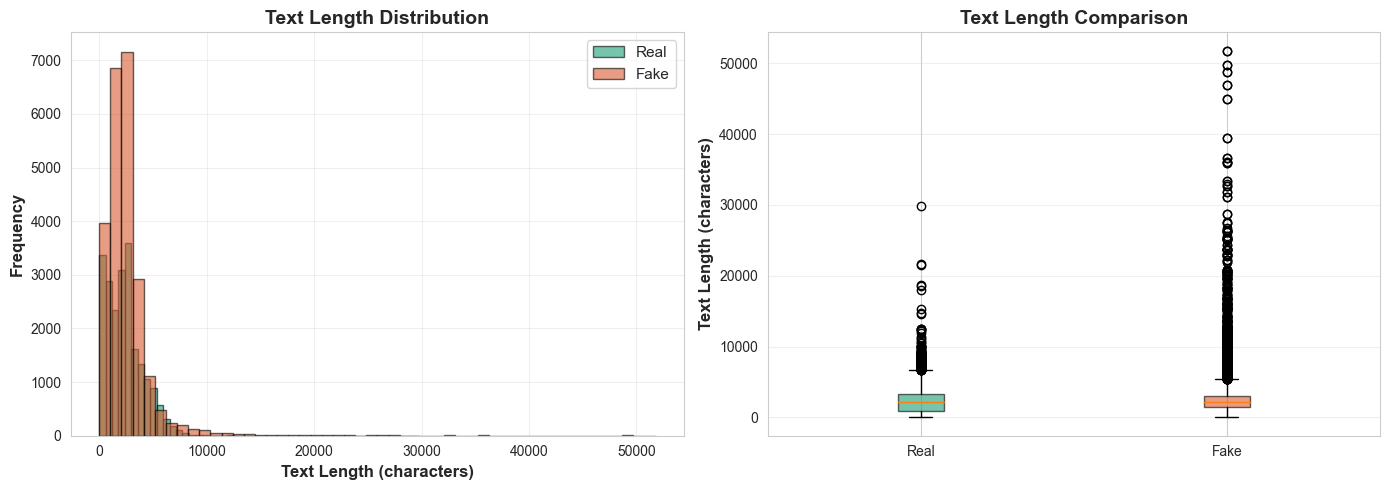

✓ Saved: eda_text_length.png


In [9]:
# 2. Text Length Distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
for label, color in zip([0, 1], colors):
    data = df[df['label'] == label]['text_length']
    label_name = 'Real' if label == 0 else 'Fake'
    axes[0].hist(data, bins=50, alpha=0.6, label=label_name, color=color, edgecolor='black')

axes[0].set_xlabel('Text Length (characters)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Frequency', fontsize=12, fontweight='bold')
axes[0].set_title('Text Length Distribution', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(alpha=0.3)

# Box plot
data_to_plot = [df[df['label'] == 0]['text_length'], df[df['label'] == 1]['text_length']]
bp = axes[1].boxplot(data_to_plot, labels=['Real', 'Fake'], patch_artist=True)

for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)

axes[1].set_ylabel('Text Length (characters)', fontsize=12, fontweight='bold')
axes[1].set_title('Text Length Comparison', fontsize=14, fontweight='bold')
axes[1].grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('../notebooks/eda_text_length.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Saved: eda_text_length.png")

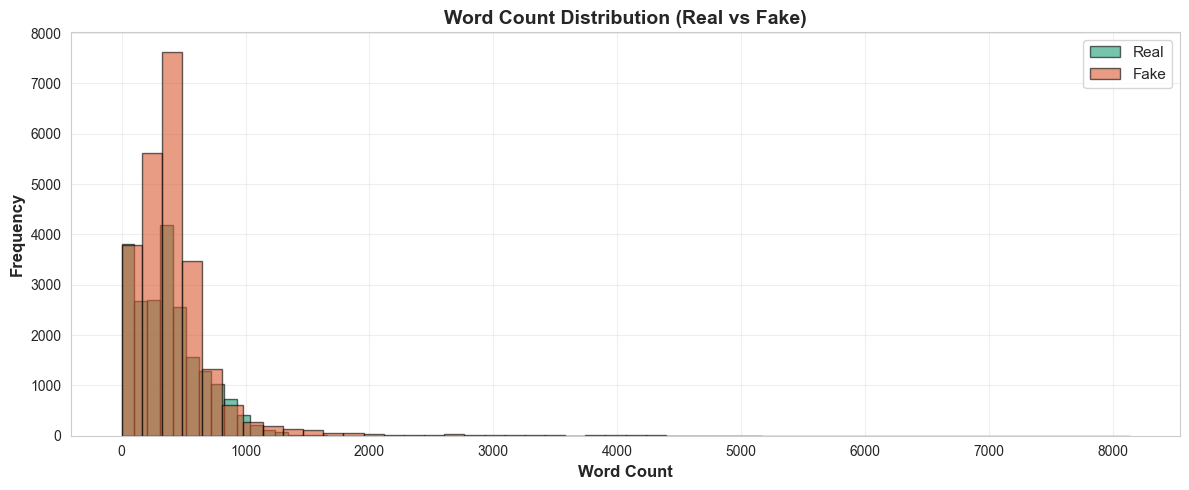

✓ Saved: eda_word_count.png


In [10]:
# 3. Word Count Distribution
fig, ax = plt.subplots(1, 1, figsize=(12, 5))

for label, color in zip([0, 1], colors):
    data = df[df['label'] == label]['word_count']
    label_name = 'Real' if label == 0 else 'Fake'
    ax.hist(data, bins=50, alpha=0.6, label=label_name, color=color, edgecolor='black')

ax.set_xlabel('Word Count', fontsize=12, fontweight='bold')
ax.set_ylabel('Frequency', fontsize=12, fontweight='bold')
ax.set_title('Word Count Distribution (Real vs Fake)', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../notebooks/eda_word_count.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Saved: eda_word_count.png")

## 6. Sample Articles

In [11]:
# Sample real articles
print("="*80)
print("SAMPLE REAL ARTICLES (label=0)")
print("="*80)
real_samples = df[df['label'] == 0].head(3)
for idx, (i, row) in enumerate(real_samples.iterrows(), 1):
    print(f"\n[Real Article {idx}]")
    print(f"Title: {row['title'][:80]}...")
    print(f"Text: {row['text'][:150]}...")
    print(f"Author: {row.get('author', 'N/A')}")

SAMPLE REAL ARTICLES (label=0)

[Real Article 1]
Title: As U.S. budget fight looms, Republicans flip their fiscal script...
Text: WASHINGTON (Reuters) - The head of a conservative Republican faction in the U.S. Congress, who voted this month for a huge expansion of the national d...
Author: N/A

[Real Article 2]
Title: U.S. military to accept transgender recruits on Monday: Pentagon...
Text: WASHINGTON (Reuters) - Transgender people will be allowed for the first time to enlist in the U.S. military starting on Monday as ordered by federal c...
Author: N/A

[Real Article 3]
Title: Senior U.S. Republican senator: 'Let Mr. Mueller do his job'...
Text: WASHINGTON (Reuters) - The special counsel investigation of links between Russia and President Trump’s 2016 election campaign should continue without ...
Author: N/A


In [12]:
# Sample fake articles
print("\n" + "="*80)
print("SAMPLE FAKE ARTICLES (label=1)")
print("="*80)
fake_samples = df[df['label'] == 1].head(3)
for idx, (i, row) in enumerate(fake_samples.iterrows(), 1):
    print(f"\n[Fake Article {idx}]")
    print(f"Title: {row['title'][:80]}...")
    print(f"Text: {row['text'][:150]}...")
    print(f"Author: {row.get('author', 'N/A')}")


SAMPLE FAKE ARTICLES (label=1)

[Fake Article 1]
Title:  Donald Trump Sends Out Embarrassing New Year’s Eve Message; This is Disturbing...
Text: Donald Trump just couldn t wish all Americans a Happy New Year and leave it at that. Instead, he had to give a shout out to his enemies, haters and  t...
Author: N/A

[Fake Article 2]
Title:  Drunk Bragging Trump Staffer Started Russian Collusion Investigation...
Text: House Intelligence Committee Chairman Devin Nunes is going to have a bad day. He s been under the assumption, like many of us, that the Christopher St...
Author: N/A

[Fake Article 3]
Title:  Sheriff David Clarke Becomes An Internet Joke For Threatening To Poke People ‘I...
Text: On Friday, it was revealed that former Milwaukee Sheriff David Clarke, who was being considered for Homeland Security Secretary in Donald Trump s admi...
Author: N/A


## 7. Key Observations & Notes

In [13]:
observations = f"""
📊 KEY OBSERVATIONS FROM EDA:

1. DATASET SIZE:
   • Total articles: {len(df):,}
   • Real articles: {len(df[df['label'] == 0]):,} ({len(df[df['label'] == 0])/len(df)*100:.1f}%)
   • Fake articles: {len(df[df['label'] == 1]):,} ({len(df[df['label'] == 1])/len(df)*100:.1f}%)
   • Dataset is SLIGHTLY imbalanced (52% fake, 48% real)

2. TEXT LENGTH:
   • Average: {df['text_length'].mean():.0f} characters
   • Real articles: {df[df['label'] == 0]['text_length'].mean():.0f} avg chars
   • Fake articles: {df[df['label'] == 1]['text_length'].mean():.0f} avg chars
   • Fake articles tend to be LONGER

3. WORD COUNT:
   • Average: {df['word_count'].mean():.0f} words
   • Range: {df['word_count'].min()} - {df['word_count'].max()} words

4. DATA QUALITY:
   • Missing values: {df.isnull().sum().sum()} (NONE) ✓
   • Columns: {list(df.columns)}

5. NEXT STEPS:
   • Week 2: Text preprocessing (cleaning, tokenization, TF-IDF)
   • Remove URLs, punctuation, lowercase conversion
   • Apply NLTK stopwords & lemmatization
   • Create TF-IDF vectors for ML training
"""

print(observations)


📊 KEY OBSERVATIONS FROM EDA:

1. DATASET SIZE:
   • Total articles: 44,898
   • Real articles: 21,417 (47.7%)
   • Fake articles: 23,481 (52.3%)
   • Dataset is SLIGHTLY imbalanced (52% fake, 48% real)

2. TEXT LENGTH:
   • Average: 2469 characters
   • Real articles: 2383 avg chars
   • Fake articles: 2547 avg chars
   • Fake articles tend to be LONGER

3. WORD COUNT:
   • Average: 405 words
   • Range: 0 - 8135 words

4. DATA QUALITY:
   • Missing values: 0 (NONE) ✓
   • Columns: ['title', 'text', 'subject', 'date', 'label', 'text_length', 'word_count']

5. NEXT STEPS:
   • Week 2: Text preprocessing (cleaning, tokenization, TF-IDF)
   • Remove URLs, punctuation, lowercase conversion
   • Apply NLTK stopwords & lemmatization
   • Create TF-IDF vectors for ML training



In [14]:
# Save the analysis
print("\n✅ WEEK 1 EDA COMPLETE!")
print("\nDeliverables:")
print(f"  ✓ Dataset loaded ({len(df):,} articles)")
print("  ✓ Basic exploratory analysis done")
print("  ✓ 3 visualizations created:")
print("    - eda_class_dist.png (class distribution)")
print("    - eda_text_length.png (text length histogram)")
print("    - eda_word_count.png (word count distribution)")
print("  ✓ Key observations documented")
print("\nReady for Week 2: NLP Preprocessing!")


✅ WEEK 1 EDA COMPLETE!

Deliverables:
  ✓ Dataset loaded (44,898 articles)
  ✓ Basic exploratory analysis done
  ✓ 3 visualizations created:
    - eda_class_dist.png (class distribution)
    - eda_text_length.png (text length histogram)
    - eda_word_count.png (word count distribution)
  ✓ Key observations documented

Ready for Week 2: NLP Preprocessing!
